# <center>**04_eda_dataset_statistics**</center>

### Table of Contents

1. **Notebook Overview**  
   - Objective of the descriptive analysis  
   - Description of the dataset 
   - Role of these databases in the CNN training and evaluation pipeline  

2. **Environment Setup**  
   - Import of required libraries  
   - Definition of file paths and basic configuration  

3. **Load Databases**  
   - Load the three anonymised datasets from feather files  
   - Basic integrity checks (shape, column names, first rows)  

4. **Variable Inspection**  
   - Data types and basic cleaning  
   - Harmonisation of key variables (e.g. calcification label coding)  

5. **Descriptive Statistics for Quantitative Variables**  
   - Age computation from birth date and radiograph date  
   - Exposure Index (EI)  
   - Summary statistics (mean, SD, median, IQR, range, skewness, kurtosis)  
   - Comparison of age and EI 
   - Age and EI stratified by calcific tendinopathy (No / Yes)  
   - Descriptive tables for each dataset  
   - Visualisation: histograms, boxplots and violin plots by group  

6. **Descriptive Statistics for Categorical Variables**  
   - Frequency tables for sex, laterality, projection, manufacturer and acquisition settings  
   - Distribution by dataset  
   - Distribution stratified by calcification status (No / Yes)  
   - Contingency tables (e.g. sex vs calcification, projection vs calcification)
   - Visualisation: barplots by group  

7. **Temporal Distribution of Radiographs**  
   - Annual frequency tables per dataset  
   - Combined and per-dataset visualisation of radiograph counts by year  

8. **Summary and Conclusions**  
    - Global description of the study population across datasets  
    - Differences between patients with and without calcific tendinopathy  
    - Implications for model development and external validation  


### **1. Notebook Overview**

This notebook performs a descriptive statistical analysis of the anonymised clinical and imaging metadata used throughout the experiment for training and evaluating convolutional neural networks (CNNs) and hybrid models in a binary classification setting (presence vs absence of rotator cuff tendon calcifications) in two institutions. The complete dataset is analysed, reflecting different time periods, acquisition systems and clinical workflows.

The goal is to characterise the study population and imaging conditions in terms of age, sex, laterality, projection type, exposure index and acquisition hardware, both globally and stratified by calcification status. Quantitative variables are summarised using standard descriptive statistics and visualised with histograms, boxplots and violin plots, while categorical variables are described through frequency tables and barplots.

These descriptive results provide context for the subsequent CNN and hybrid model experiments, helping to understand potential sources of distribution shift between datasets (e.g. demographic or technical differences) and to interpret model performance in light of the underlying data characteristics. No patient-identifying information is used or displayed in this notebook.

### **2. Environment Setup**

In [10]:
# Environment setup: core libraries for descriptive statistics and plotting

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, HTML

# Silence non-critical warnings (e.g. deprecations) to keep the notebook output clean
warnings.filterwarnings("ignore", category=FutureWarning)

# Basic plotting style
sns.set_style("whitegrid")


### **3. Load Databases**

In [4]:
# === Database paths (Feather format) ===
path_train = 'train_subset.feather'
path_internal = 'internal_validation_test.feather'
path_external = 'external_generalization_test.feather'

# === Load the three databases ===
df_train = pd.read_feather(path_train)
df_internal = pd.read_feather(path_internal)
df_external = pd.read_feather(path_external)

# === Print shapes to confirm ===
print(f"Base 1 (Train) - Shape: {df_train.shape}")
print(f"Base 2 (Internal Test) - Shape: {df_internal.shape}")
print(f"Base 3 (External Test) - Shape: {df_external.shape}")

# === Print First Rows ===
print("\n First database (Train):")
display(df_train.head(0))

print("\n Second database (Internal Test):")
display(df_internal.head(0))

print("\n Third database (External Test):")
display(df_external.head(0))

Base 1 (Train) - Shape: (4268, 20)
Base 2 (Internal Test) - Shape: (480, 20)
Base 3 (External Test) - Shape: (308, 16)

 First database (Train):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,label_CalTend,label_CalTend_sub,label_CalTend_supr,label_CalTend_infr,size,complentary_expl,lat_rx



 Second database (Internal Test):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,label_CalTend,label_CalTend_sub,label_CalTend_supr,label_CalTend_infr,size,complentary_expl,lat_rx



 Third database (External Test):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,complentary_expl,label_CalTend,lat_rx


### **4. Variable Inspection**

In [5]:
# === Check dtypes for each dataset ===

print("\nData types – Base 1 (Train)")
print(df_train.dtypes)

print("\nData types – Base 2 (Internal Test)")
print(df_internal.dtypes)

print("\nData types – Base 3 (External Test)")
print(df_external.dtypes)


Data types – Base 1 (Train)
Unnamed: 0              int64
NHC                    object
epi_cod                object
rx_cod                 object
proje                  object
manufacturer           object
manufacturer_model     object
station_name           object
voilutfunction         object
birthdate              object
sex                    object
ei                    float64
date_rx                object
label_CalTend           int64
label_CalTend_sub      object
label_CalTend_supr     object
label_CalTend_infr     object
size                  float64
complentary_expl       object
lat_rx                 object
dtype: object

Data types – Base 2 (Internal Test)
Unnamed: 0              int64
NHC                    object
epi_cod                object
rx_cod                 object
proje                  object
manufacturer           object
manufacturer_model     object
station_name           object
voilutfunction         object
birthdate              object
sex                 

### **5. Descriptive Statistics for Quantitative Variables**

In [7]:
def normalize_yes_no(series):
    mapping = {
        0: 'No', 1: 'Yes',
        '0': 'No', '1': 'Yes',
        'No': 'No', 'NO': 'No', 'no': 'No', 'N': 'No',
        'Sí': 'Yes', 'Si': 'Yes', 'SI': 'Yes', 'sí': 'Yes',
        'Yes': 'Yes', 'YES': 'Yes', 'yes': 'Yes',
        True: 'Yes', False: 'No'
    }
    s = series.replace(mapping)
    return pd.Categorical(s, categories=['No', 'Yes'], ordered=True)

# === Apply normalization to all three datasets ===
for df in [df_train, df_internal, df_external]:
    df['label_CalTend'] = normalize_yes_no(df['label_CalTend'])

# === Verification ===
print("Base 1 (Train):", df_train['label_CalTend'].unique())
print("Base 2 (Internal):", df_internal['label_CalTend'].unique())
print("Base 3 (External):", df_external['label_CalTend'].unique())

Base 1 (Train): ['No', 'Yes']
Categories (2, object): ['No' < 'Yes']
Base 2 (Internal): ['Yes', 'No']
Categories (2, object): ['No' < 'Yes']
Base 3 (External): ['Yes', 'No']
Categories (2, object): ['No' < 'Yes']


In [8]:
def sdescriptive(df, var, round_=0, save_path=False):
    """
    Compute a set of descriptive statistics for a numeric variable in a DataFrame.

    This function calculates standard descriptive measures such as mean, standard deviation,
    median, interquartile range (IQR), range, minimum, maximum, skewness, and kurtosis.
    By default, all values are rounded to the specified number of decimals (round_). If
    a file path is provided (save_path), the resulting statistics are also saved in CSV
    and Excel formats.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the dataset.
    var : str
        Name of the column (variable) for which descriptive statistics will be computed.
    round_ : int, optional
        Number of decimal places to which the results should be rounded. Defaults to 0.
    save_path : bool or str, optional
        If False (default), the function does not save any file. If a string is provided,
        it is used as the base path (without extension) for saving the results to CSV and
        Excel files (e.g. 'path/filename').

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing the descriptive statistics for the specified variable,
        with the following metrics as rows:
        - Mean
        - Standard deviation
        - Median
        - Interquartile range (IQR)
        - Range
        - Minimum
        - Maximum
        - Skewness
        - Kurtosis (Fisher definition: normal distribution == 0)
    """

    # Basic descriptive statistics: count, mean, std, min, quartiles, max
    stats_var = df[var].describe().round(round_)

    # Interquartile range and range
    stats_var['iqr'] = stats_var['75%'] - stats_var['25%']
    stats_var['range'] = stats_var['max'] - stats_var['min']

    # Skewness and kurtosis (Fisher definition: normal == 0)
    stats_var['skew'] = df[var].skew().round(round_)
    stats_var['kurt'] = df[var].kurt().round(round_)

    # Select and reorder statistics of interest
    stats_var = stats_var.loc[
        ['mean', 'std', '50%', 'iqr', 'range', 'min', 'max', 'skew', 'kurt']
    ].to_frame('Value')

    # Rename index to English labels and rename the column to the variable name
    stats_var.index = [
        'Mean',
        'Std. deviation',
        'Median',
        'IQR',
        'Range',
        'Min',
        'Max',
        'Skewness',
        'Kurtosis'
    ]
    stats_var = stats_var.rename(columns={'Value': var})

    # Optionally save to CSV and Excel
    if save_path is not False:
        stats_var.to_csv(f'{save_path}.csv')
        stats_var.to_excel(f'{save_path}.xlsx')

    return stats_var


In [9]:
# === List of DataFrames and corresponding names ===
bases = [df_train, df_internal, df_external]
names = ['Base 1 (Train)', 'Base 2 (Internal)', 'Base 3 (External)']

# Lists to store results
stats_age_list = []
stats_ei_list = []

for df in bases:
    # === Convert date columns to datetime ===
    df['birthdate'] = pd.to_datetime(df['birthdate'], errors='coerce')
    df['date_rx'] = pd.to_datetime(df['date_rx'], format='mixed', dayfirst=True, errors='coerce')

    # === Compute age in years ===
    df['age_years'] = (df['date_rx'] - df['birthdate']).dt.days / 365.25

    # Age: continuous clinical variable (1 decimal)
    stats_age = sdescriptive(df=df, var='age_years', round_=1)

    # EI: technical index (0 decimals)
    stats_ei = sdescriptive(df=df, var='ei', round_=0)

    stats_age_list.append(stats_age)
    stats_ei_list.append(stats_ei)

# === Combine results (columns side-by-side) ===
df_stats_age = pd.concat(stats_age_list, axis=1)
df_stats_age.columns = names

df_stats_ei = pd.concat(stats_ei_list, axis=1)
df_stats_ei.columns = names

def _format_descriptive_table(df):
    """Format integers to remove .0 while keeping floats."""
    def fmt(x):
        try:
            x_float = float(x)
        except (TypeError, ValueError):
            return x
        return int(x_float) if x_float.is_integer() else x_float
    out = df.copy()
    for col in out.columns:
        out[col] = out[col].apply(fmt)
    return out

# === Final Display ===
df_stats_age_display = _format_descriptive_table(df_stats_age)
df_stats_ei_display = _format_descriptive_table(df_stats_ei)

print("Descriptive statistics – Age (years):")
display(df_stats_age_display)

print("\nDescriptive statistics – Exposure Index (EI):")
display(df_stats_ei_display)

Descriptive statistics – Age (years):


,Base 1 (Train),Base 2 (Internal),Base 3 (External)
Mean,52.0,48.1,44.6
Std. deviation,13.3,11.6,12.2
Median,51.3,49.0,46.9
IQR,17.4,12.7,13.6
Range,77.5,65.6,82.8
Min,10.9,13.6,10.4
Max,88.4,79.2,93.2
Skewness,0.0,-0.1,-0.4
Kurtosis,0.0,0.9,1.0



Descriptive statistics – Exposure Index (EI):


,Base 1 (Train),Base 2 (Internal),Base 3 (External)
Mean,120,98,98
Std. deviation,92,82,72
Median,98,77,98
IQR,134,96,62
Range,397,425,394
Min,3,6,6
Max,400,431,400
Skewness,1,1,2
Kurtosis,0,1,4


In [11]:
# === Descriptive statistics for age and EI by tendon calcification status (No / Yes) ===

stats_by_tc_list = []
bases = [df_train, df_internal, df_external]
names = ['Base 1 (Train)', 'Base 2 (Internal)', 'Base 3 (External)']

for df in bases:
    df_valid = df.copy()

    # === Ensure age_years exists ===
    if 'age_years' not in df_valid.columns:
        df_valid['birthdate'] = pd.to_datetime(df_valid['birthdate'], errors='coerce')
        df_valid['date_rx'] = pd.to_datetime(df_valid['date_rx'], format='mixed', dayfirst=True, errors='coerce')
        df_valid['age_years'] = (df_valid['date_rx'] - df_valid['birthdate']).dt.days / 365.25

    # === Drop rows with missing values in key columns ===
    df_valid = df_valid.dropna(subset=['age_years', 'ei', 'label_CalTend'])

    # === Group by presence of calcification ===
    # Age: continuous clinical variable (1 decimal)
    stats_age_tc = df_valid.groupby('label_CalTend').apply(
        lambda g: sdescriptive(g, var='age_years', round_=1),
        include_groups=False
    )

    # EI: technical index (0 decimals)
    stats_ei_tc = df_valid.groupby('label_CalTend').apply(
        lambda g: sdescriptive(g, var='ei', round_=0),
        include_groups=False
    )

    # === Combine age and EI statistics side by side ===
    df_stats_edad_ei_tc = pd.concat(
        [stats_age_tc, stats_ei_tc],
        axis=1,
        keys=['Age (years)', 'Exposure Index (EI)']
    )

    # === Apply formatting (remove .0 from integers) ===
    df_stats_edad_ei_tc = _format_descriptive_table(df_stats_edad_ei_tc)
    stats_by_tc_list.append(df_stats_edad_ei_tc)

# === Display results for each dataset ===
for name, df_stats in zip(names, stats_by_tc_list):
    print(f"\nDescriptive statistics by tendon calcification status – {name}:")
    display(df_stats)


Descriptive statistics by tendon calcification status – Base 1 (Train):


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  52.3                 123
              Std. deviation        15.7                  92
              Median                52.7                 102
              IQR                   21.9                 131
              Range                 77.5                 396
              Min                   10.9                   4
              Max                   88.4                 400
              Skewness              -0.3                   1
              Kurtosis              -0.5                   0
Yes           Mean                  51.8                 116
              Std. deviation        10.4                  92
              Median                50.2                  95
              IQR                   13.7                 136
              Range                 57.4                 397
              Min                   27.3                   3
              Max                   84.7                 400
              Skewness               0.7                   1
              Kurtosis               0.2                   0


Descriptive statistics by tendon calcification status – Base 2 (Internal):


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  46.9                 103
              Std. deviation        14.2                  79
              Median                47.0                  88
              IQR                   14.4                  89
              Range                 65.6                 394
              Min                   13.6                   6
              Max                   79.2                 400
              Skewness               0.0                   1
              Kurtosis               0.1                   1
Yes           Mean                  49.4                  92
              Std. deviation         8.3                  85
              Median                49.9                  66
              IQR                    8.2                  94
              Range                 38.0                 425
              Min                   32.8                   6
              Max                   70.8                 431
              Skewness               0.3                   1
              Kurtosis               0.2                   2


Descriptive statistics by tendon calcification status – Base 3 (External):


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  40.0                  92
              Std. deviation        13.0                  67
              Median                43.1                  96
              IQR                   19.7                  67
              Range                 49.5                 389
              Min                   10.4                  11
              Max                   59.9                 400
              Skewness              -0.5                   2
              Kurtosis              -0.8                   7
Yes           Mean                  49.1                 104
              Std. deviation         9.5                  76
              Median                50.0                 100
              IQR                   10.7                  65
              Range                 77.0                 394
              Min                   16.2                   6
              Max                   93.2                 400
              Skewness               0.7                   2
              Kurtosis               3.7                   3

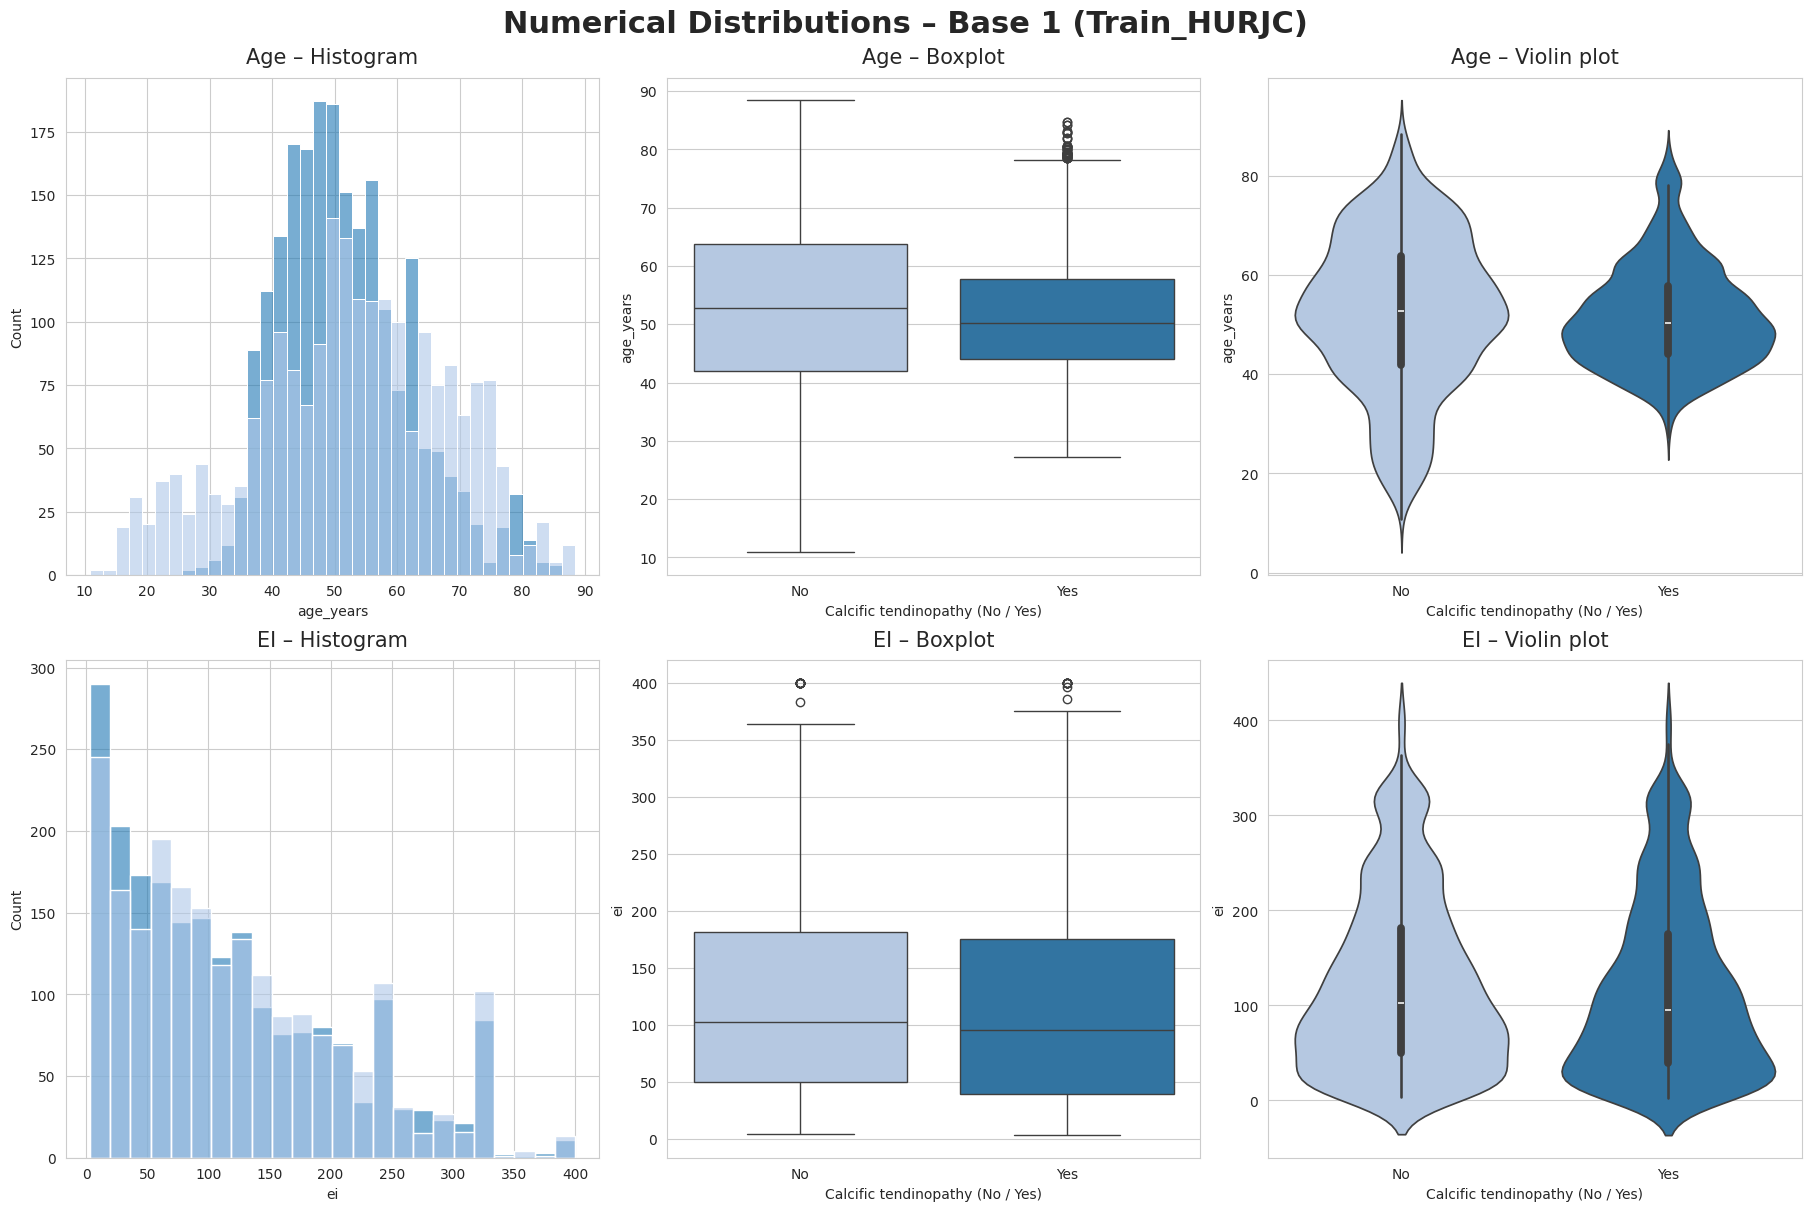

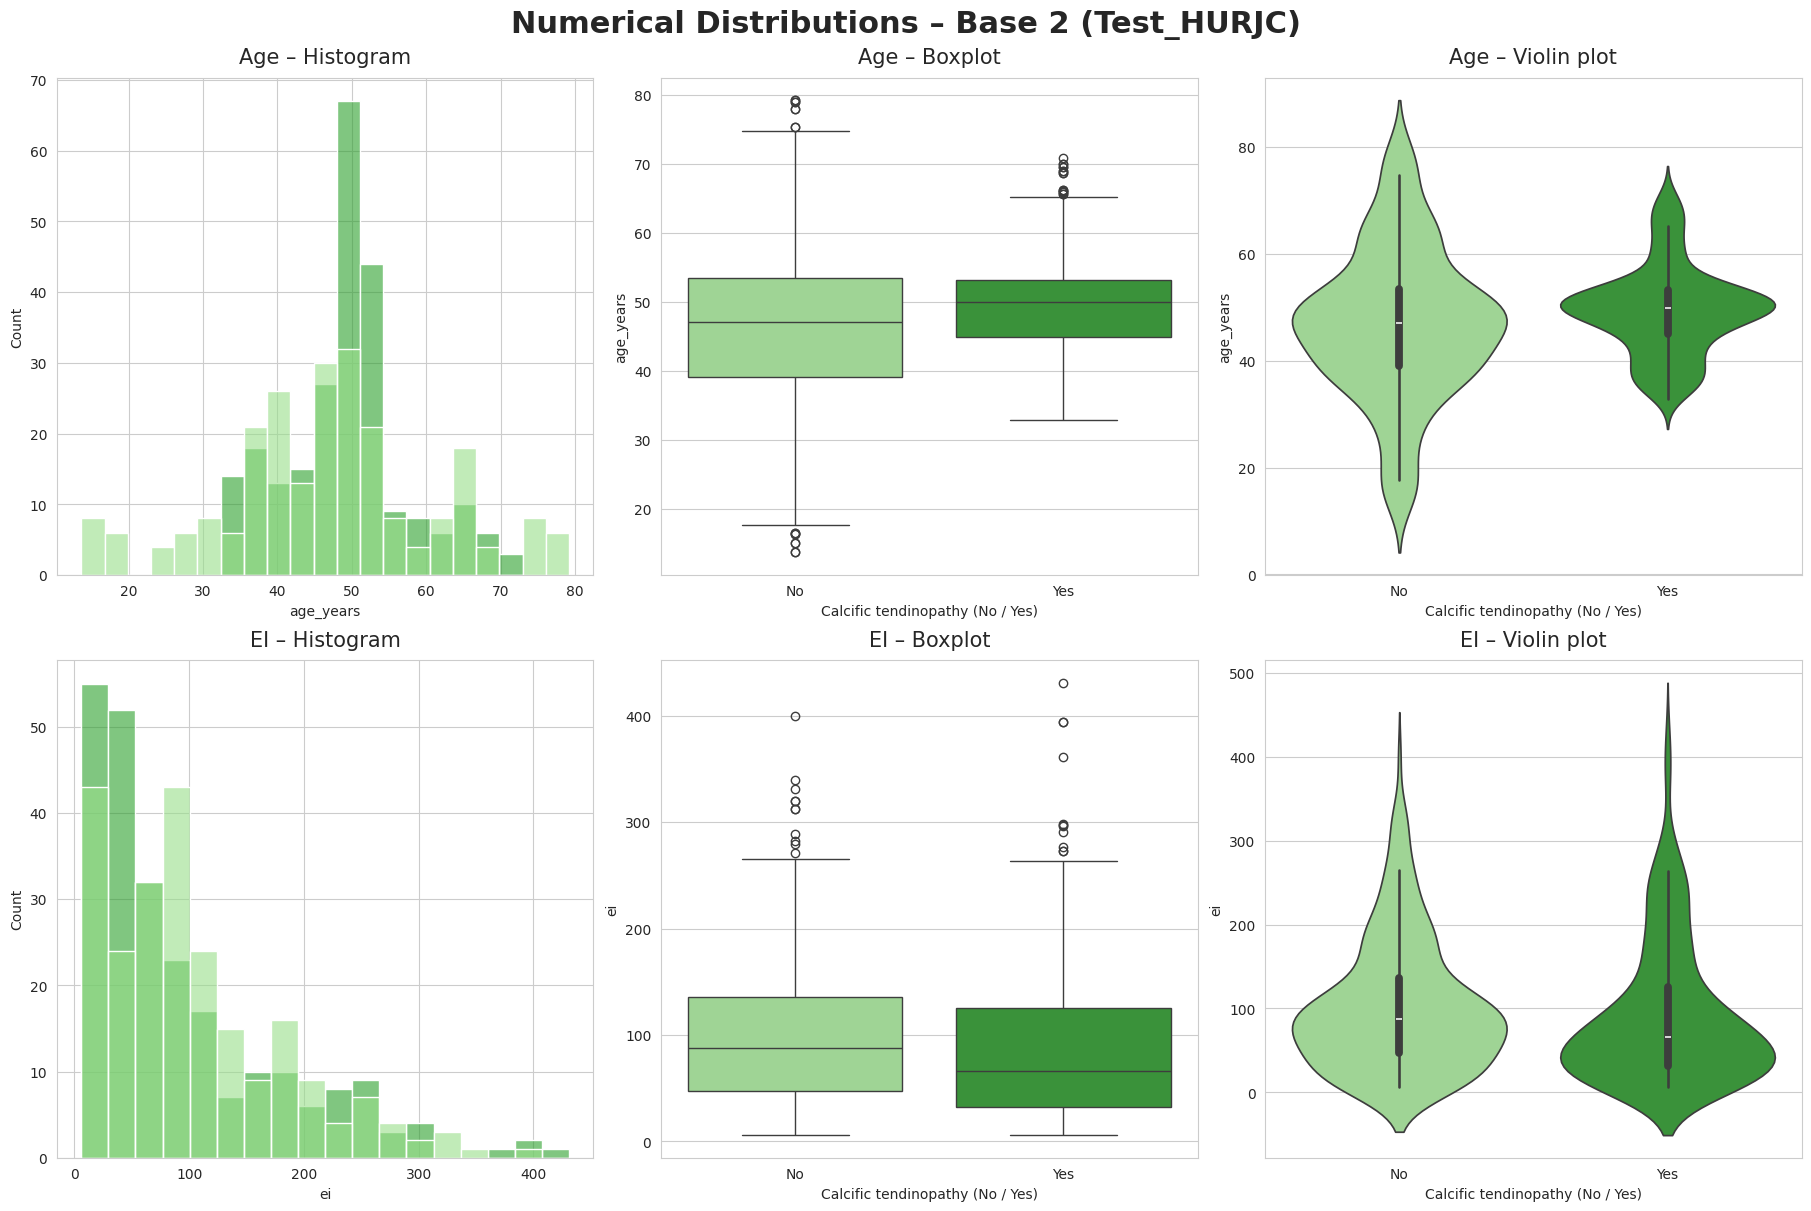

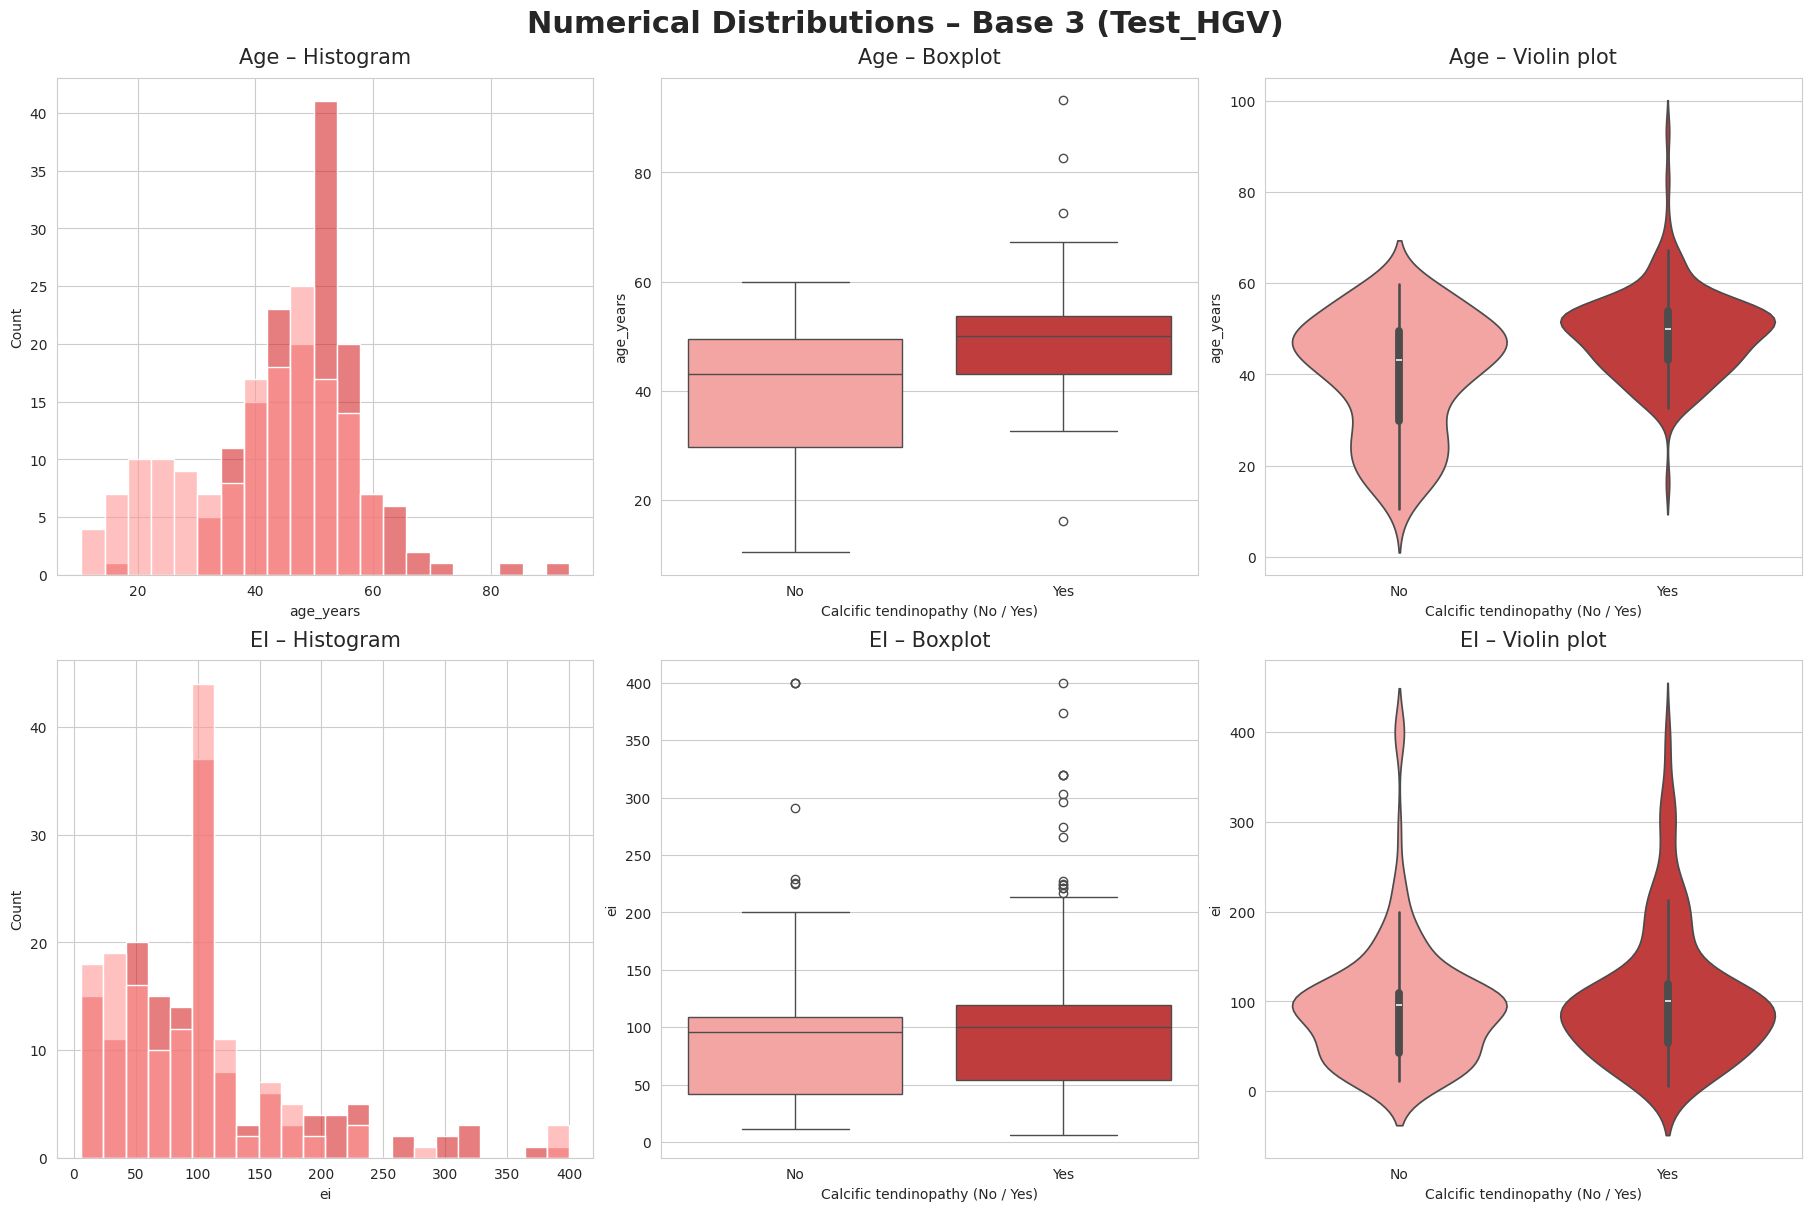

In [26]:
# === Color palettes per dataset (Healthy: Light / CTRC: Dark) ===
palette_b1 = ['#aec7e8', '#1f77b4']  
palette_b2 = ['#98df8a', '#2ca02c']  
palette_b3 = ['#ff9896', '#d62728'] 

def plot_database_distributions(df, base_name, current_palette):
    # === Ensure consistent categorical order ===
    df['label_CalTend'] = pd.Categorical(
        df['label_CalTend'], 
        categories=['No', 'Yes'], 
        ordered=True
    )

    # Use light tone for 'No' and dark tone for 'Yes'
    palette_dict = {'No': current_palette[0], 'Yes': current_palette[1]}
    sns.set_style('whitegrid')

    # === Prepare data (Dates and Age) ===
    df_plot = df.copy()
    df_plot['birthdate'] = pd.to_datetime(df_plot['birthdate'], errors='coerce')
    df_plot['date_rx'] = pd.to_datetime(df_plot['date_rx'], format='mixed', dayfirst=True, errors='coerce')
    df_plot['age_years'] = (df_plot['date_rx'] - df_plot['birthdate']).dt.days / 365.25
    df_plot = df_plot.dropna(subset=['age_years', 'ei', 'label_CalTend'])

    # 2 rows x 3 columns: Age (top), Exposure Index (bottom)
    # Using layout='constrained' to prevent overlapping titles/labels
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), layout='constrained')
    fig.suptitle(f'Numerical Distributions – {base_name}', fontsize=22, fontweight='bold')

    # ---------- AGE (top row) ----------
    sns.histplot(data=df_plot, x='age_years', hue='label_CalTend', hue_order=['No', 'Yes'], 
                 palette=palette_dict, alpha=0.6, multiple='layer', ax=axes[0, 0])
    axes[0, 0].set_title('Age – Histogram', fontsize=15, pad=10)
    
    sns.boxplot(data=df_plot, x='label_CalTend', y='age_years', order=['No', 'Yes'], 
                hue='label_CalTend', palette=palette_dict, dodge=False, ax=axes[0, 1])
    axes[0, 1].set_title('Age – Boxplot', fontsize=15, pad=10)
    
    sns.violinplot(data=df_plot, x='label_CalTend', y='age_years', order=['No', 'Yes'], 
                   hue='label_CalTend', palette=palette_dict, dodge=False, inner='box', ax=axes[0, 2])
    axes[0, 2].set_title('Age – Violin plot', fontsize=15, pad=10)

    # ---------- EXPOSURE INDEX (bottom row) ----------
    sns.histplot(data=df_plot, x='ei', hue='label_CalTend', hue_order=['No', 'Yes'], 
                 palette=palette_dict, alpha=0.6, multiple='layer', ax=axes[1, 0])
    axes[1, 0].set_title('EI – Histogram', fontsize=15, pad=10)
    
    sns.boxplot(data=df_plot, x='label_CalTend', y='ei', order=['No', 'Yes'], 
                hue='label_CalTend', palette=palette_dict, dodge=False, ax=axes[1, 1])
    axes[1, 1].set_title('EI – Boxplot', fontsize=15, pad=10)
    
    sns.violinplot(data=df_plot, x='label_CalTend', y='ei', order=['No', 'Yes'], 
                   hue='label_CalTend', palette=palette_dict, dodge=False, inner='box', ax=axes[1, 2])
    axes[1, 2].set_title('EI – Violin plot', fontsize=15, pad=10)

    # Cleanup legends and refine axis labels
    for r in range(2):
        for c in range(3):
            if axes[r, c].legend_ is not None: 
                axes[r, c].legend_.remove()
            axes[r, c].set_xlabel('Calcific tendinopathy (No / Yes)' if c > 0 else axes[r, c].get_xlabel())
            
    plt.show()

# === Run for all three bases with color coding ===
plot_database_distributions(df_train, "Base 1 (Train_HURJC)", palette_b1)
plot_database_distributions(df_internal, "Base 2 (Test_HURJC)", palette_b2)
plot_database_distributions(df_external, "Base 3 (Test_HGV)", palette_b3)

### **6. Descriptive Statistics for Quantitative Variables**

In [16]:
def freqtab(df, column, decimals=1, title="", print_=False):
    """
    Create a frequency table (count and percentage) for a categorical variable.

    The function returns a table with the absolute count and the percentage
    of each category in the specified column. Missing values are labeled as 'NA'.
    A final 'TOTAL' row is added with the overall count and 100% in the percentage column.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the data.
    column : str
        Column name for which the frequency table is computed.
    decimals : int, optional
        Number of decimal places for the percentages. Default is 1.
    title : str, optional
        Text printed before showing the table. Default is an empty string.
    print_ : bool, optional
        If True, the resulting table is displayed. Default is False.

    Returns
    -------
    pandas.DataFrame
        Frequency table with:
        - 'count (n)': absolute frequencies
        - 'percentage (%)': percentages over the total (including NA)
        plus a final 'TOTAL' row.
    """
    df2 = df.copy()

    # Ensure the column exists
    if column not in df2.columns:
        raise KeyError(f"Column '{column}' not found in DataFrame.")

    # Work with a single Series, treating missing values as 'NA'
    series = df2[column]

    # If categorical, add 'NA' to categories to ensure it is represented
    if isinstance(series.dtype, pd.CategoricalDtype):
        series = series.cat.add_categories('NA').fillna('NA')
    else:
        series = series.fillna('NA')

    # Frequency counts
    counts = series.value_counts(dropna=False)
    total = counts.sum()

    # Build table
    table = pd.DataFrame({
        'count (n)': counts,
        'percentage (%)': (counts / total * 100).round(decimals)
    })

    # Add TOTAL row with exact 100% in the percentage column
    total_row = pd.DataFrame(
        {'count (n)': [total],
         'percentage (%)': [100.0]},
        index=['TOTAL']
    )
    table = pd.concat([table, total_row], axis=0)

    # Set index name to the variable name
    table = table.rename_axis(column)

    if title:
        print(title)
    if print_:
        display(table)

    return table


In [17]:
# List of categorical variables to analyze
categorical_vars = [
    'sex', 'label_CalTend', 'lat_rx', 'proje', 'manufacturer',
    'manufacturer_model', 'station_name', 'voilutfunction', 'complentary_expl'
]

# Analysis for all three databases
bases = [df_train, df_internal, df_external]
names = ['Base 1 (Train)', 'Base 2 (Internal Test)', 'Base 3 (External Test)']

for df, name in zip(bases, names):
    print(f"\n{'='*20} {name} {'='*20}")
    
    # 1. Overall sample analysis
    print(f"\n--- {name}: Overall sample ---")
    for col in categorical_vars:
        freqtab(df=df, column=col, decimals=1, title=f'{col} (overall)', print_=True)

    # 2. Analysis for patients WITH calcific tendinopathy (Yes)
    print(f"\n--- {name}: Patients with CTRC (Yes) ---")
    df_yes = df[df['label_CalTend'] == 'Yes']
    for col in categorical_vars:
        freqtab(df=df_yes, column=col, decimals=1, title=f'{col} (Yes)', print_=True)

    # 3. Analysis for patients WITHOUT calcific tendinopathy (No)
    print(f"\n--- {name}: Patients without CTRC (No) ---")
    df_no = df[df['label_CalTend'] == 'No']
    for col in categorical_vars:
        freqtab(df=df_no, column=col, decimals=1, title=f'{col} (No)', print_=True)


==================== Base 1 (Train) ====================

--- Base 1 (Train): Overall sample ---
sex (overall)


,count (n),percentage (%)
sex,,
F,2544,59.6
M,1724,40.4
TOTAL,4268,100.0


label_CalTend (overall)


,count (n),percentage (%)
label_CalTend,,
No,2134,50.0
Yes,2134,50.0
NA,0,0.0
TOTAL,4268,100.0


lat_rx (overall)


...

,count (n),percentage (%)
station_name,,
CZC2391BGR,63,40.9
CZC2161RCP,58,37.7
PRIMO R,33,21.4
TOTAL,154,100.0


voilutfunction (No)


,count (n),percentage (%)
voilutfunction,,
LINEAR,154,100.0
TOTAL,154,100.0


complentary_expl (No)


,count (n),percentage (%)
complentary_expl,,
Sí,91,59.1
No,63,40.9
TOTAL,154,100.0


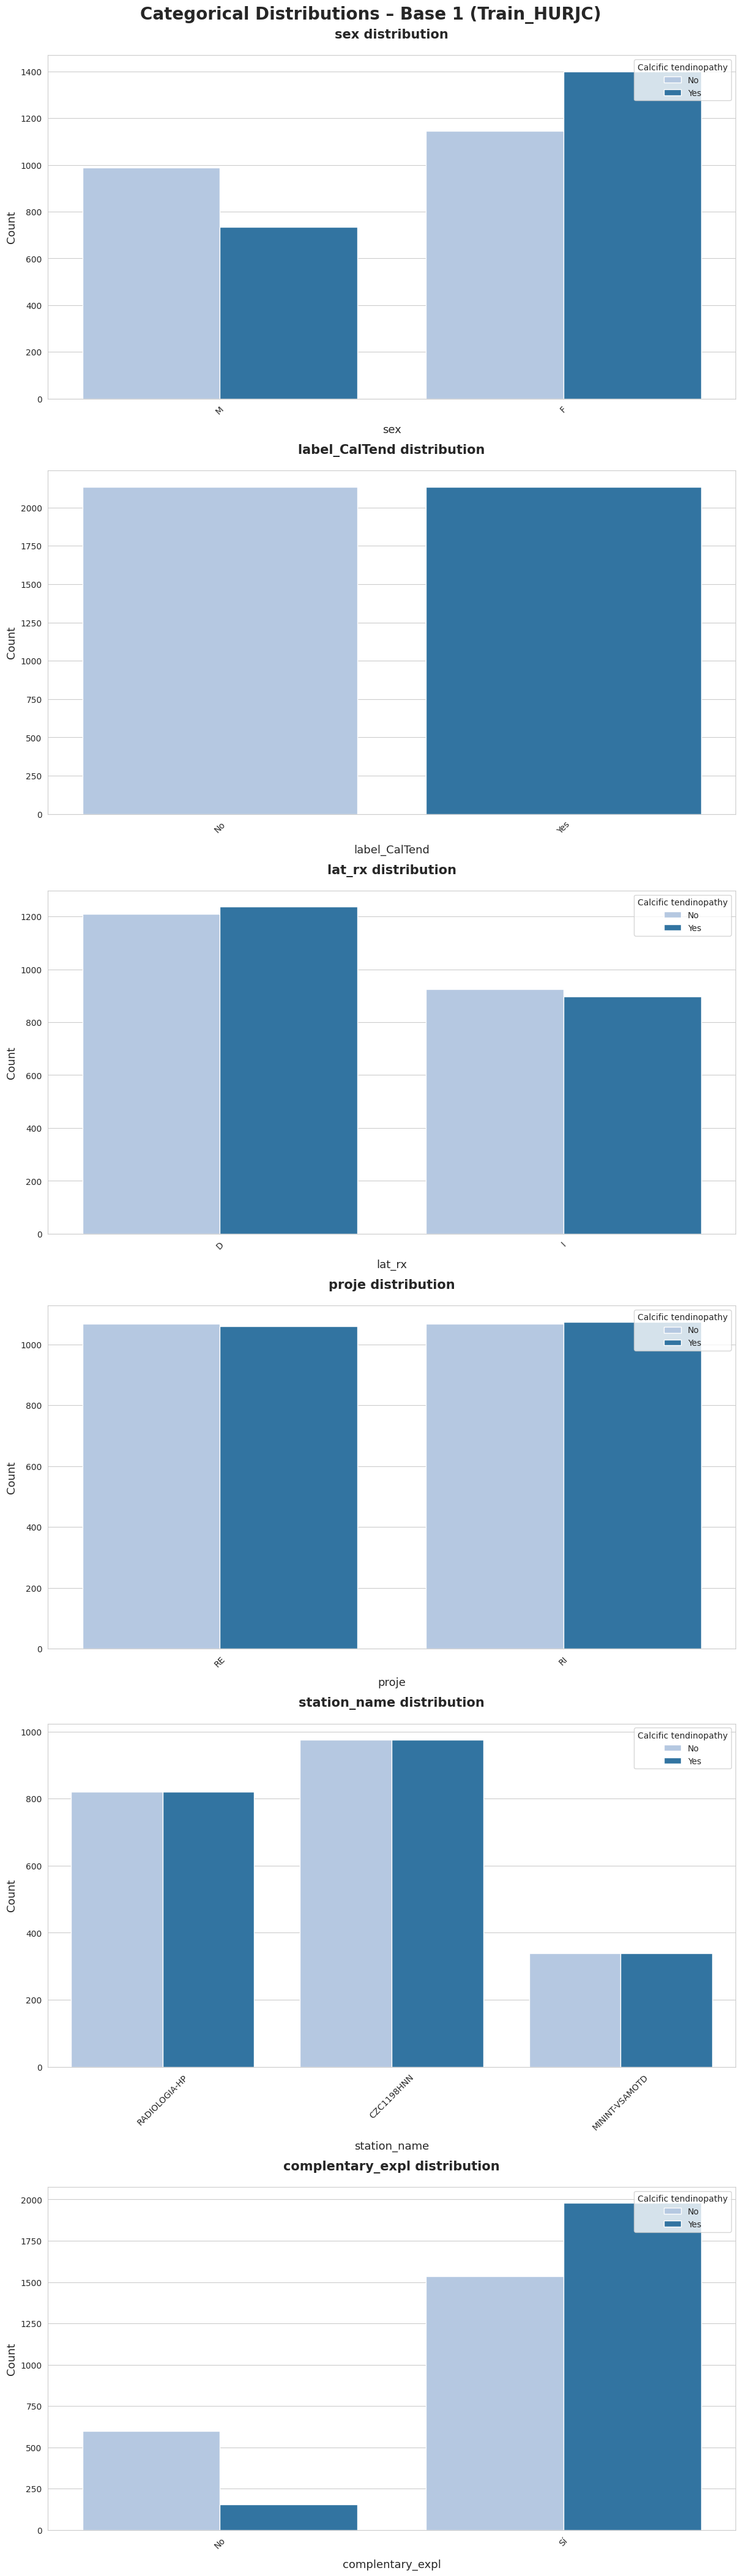

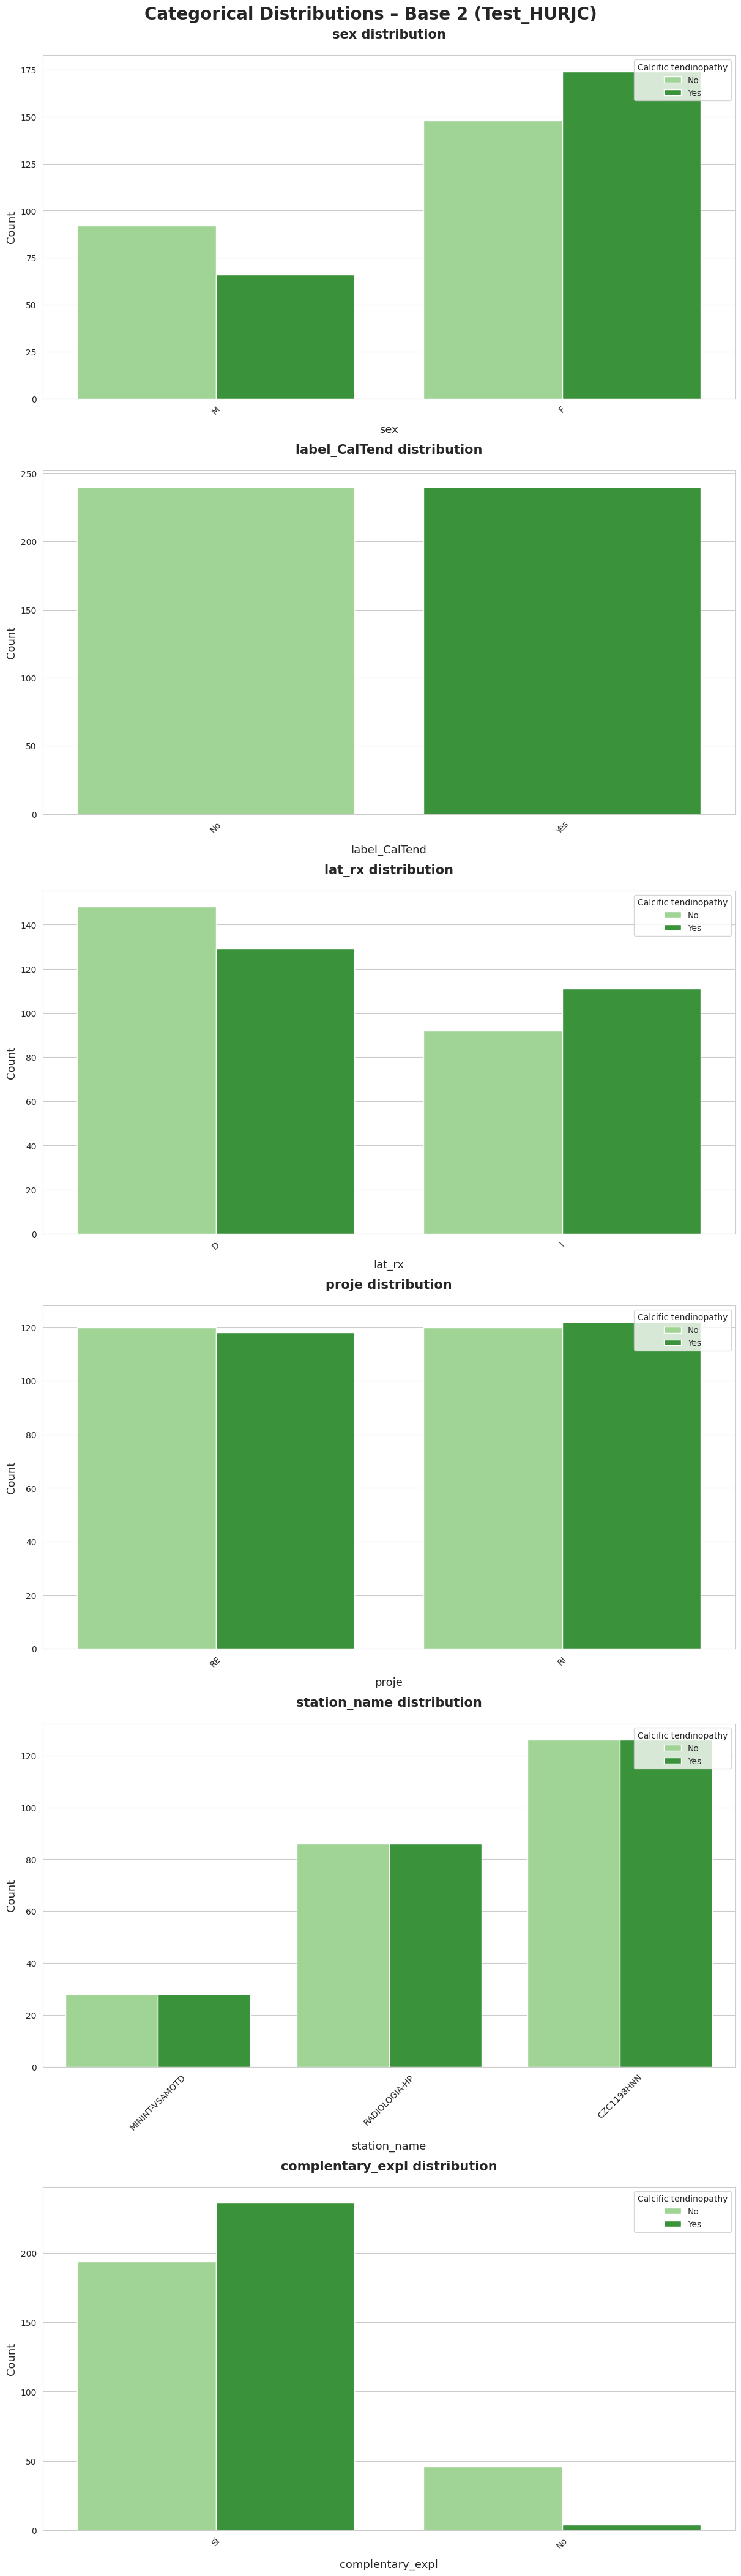

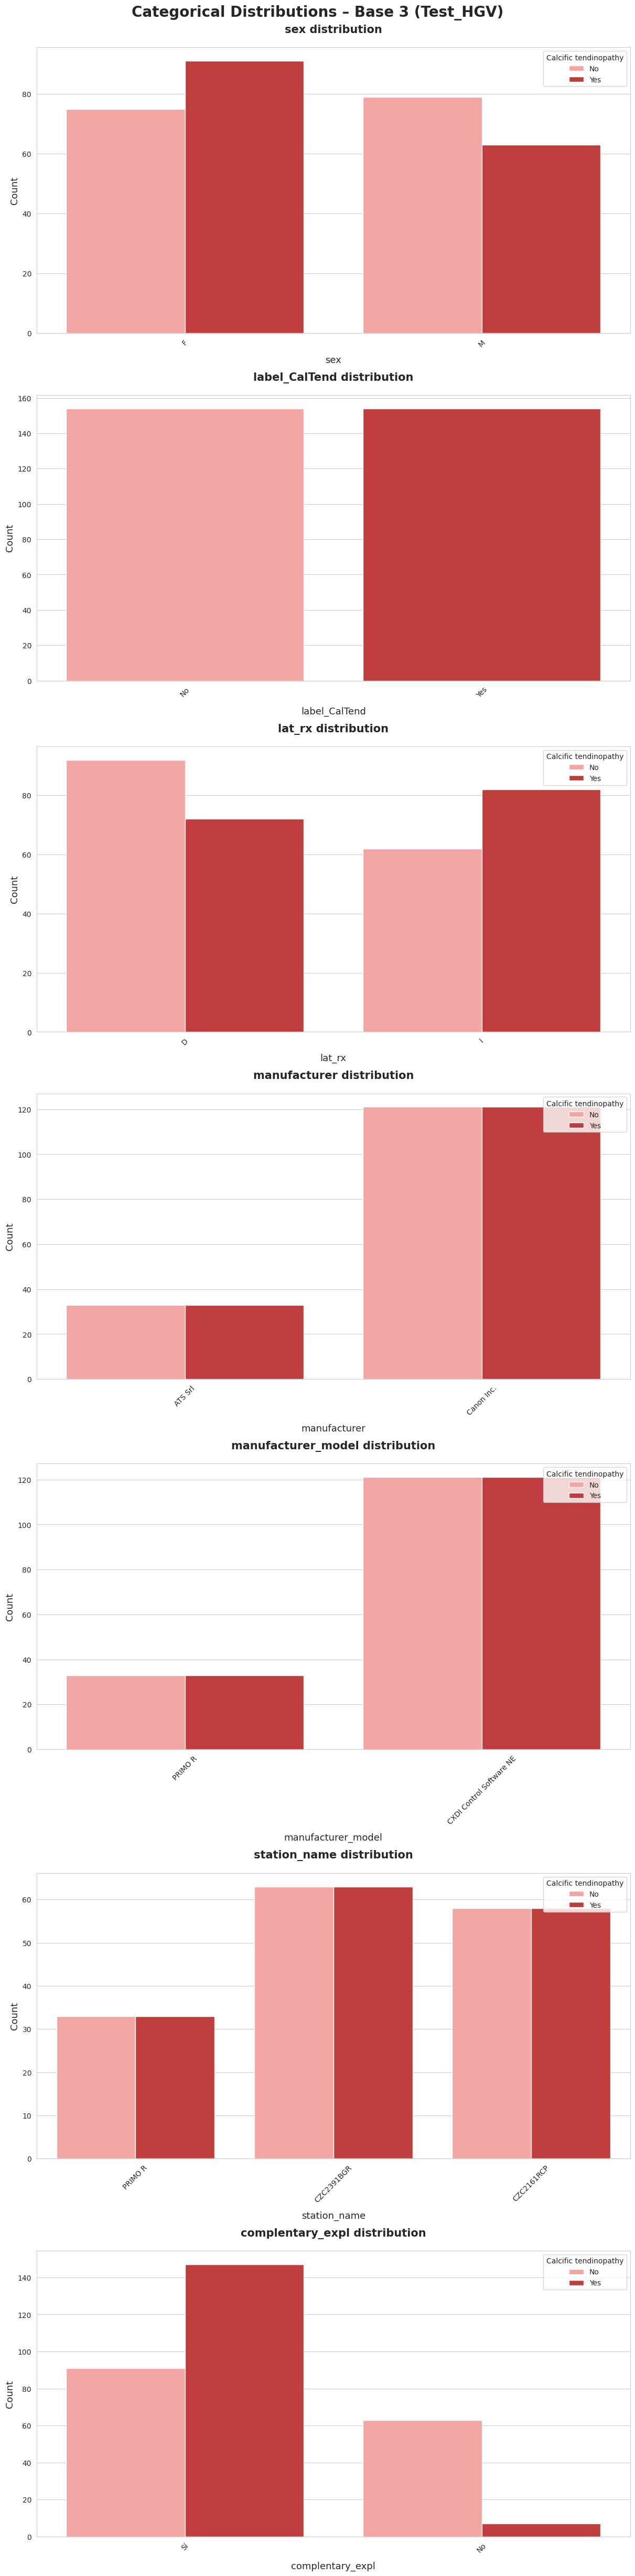

In [25]:
# === Color palettes per dataset (Healthy: Light / CTRC: Dark) ===
palette_b1 = ['#aec7e8', '#1f77b4']  
palette_b2 = ['#98df8a', '#2ca02c']  
palette_b3 = ['#ff9896', '#d62728']  

def plot_categorical_distributions(df, base_name, current_palette):
    # Standardize categorical order
    df['label_CalTend'] = pd.Categorical(df['label_CalTend'], categories=['No', 'Yes'], ordered=True)
    
    if 'lat_rx' in df.columns:
        df['lat_rx'] = pd.Categorical(df['lat_rx'], categories=['D', 'I'], ordered=True)

    sns.set_style('whitegrid')

    # Metadata variables for analysis
    categorical_vars = [
        'sex', 'label_CalTend', 'lat_rx', 'proje', 'manufacturer',
        'manufacturer_model', 'station_name', 'voilutfunction', 'complentary_expl'
    ]

    # Filter available categorical variables
    valid_categories = [var for var in categorical_vars if var in df.columns and df[var].nunique(dropna=True) > 1]
    nrows = len(valid_categories)

    # Use constrained_layout and increased vertical space to prevent overlapping
    fig, axes = plt.subplots(nrows=nrows, ncols=1, figsize=(12, 7 * nrows), layout='constrained')
    fig.suptitle(f"Categorical Distributions – {base_name}", fontsize=20, fontweight='bold')

    if nrows == 1: axes = [axes]

    for idx, var in enumerate(valid_categories):
        ax = axes[idx]
        try:
            sns.countplot(
                data=df, x=var, hue='label_CalTend', 
                hue_order=['No', 'Yes'], palette=current_palette, ax=ax
            )
            ax.set_title(f'{var} distribution', fontsize=15, fontweight='bold', pad=20)
            ax.set_xlabel(var, fontsize=13, labelpad=10)
            ax.set_ylabel('Count', fontsize=13)
            ax.tick_params(axis='x', rotation=45)
            
            if ax.legend_ is not None:
                ax.legend(title='Calcific tendinopathy', loc='upper right')
        except Exception as e:
            print(f'Error plotting {var}: {e}')
            ax.set_visible(False)

    plt.show()

# === Individual calls with specific palettes ===

# Base 1 (Train_HURJC) - Blue palette
plot_categorical_distributions(df_train, "Base 1 (Train_HURJC)", palette_b1)

# Base 2 (Test_HURJC) - Green palette
plot_categorical_distributions(df_internal, "Base 2 (Test_HURJC)", palette_b2)

# Base 3 (Test_HGV) - Red palette
plot_categorical_distributions(df_external, "Base 3 (Test_HGV)", palette_b3)

### **7. Temporal Distribution of Radiographs**


Base 1 (Train_HURJC) – Annual frequency table
--------------------------------------------------


col_0,Count,Percentage (%)
2014,2,0.05
2017,2,0.05
2018,5,0.12
2019,4,0.09
2020,20,0.47
2021,559,13.12
2022,831,19.50
2023,1603,37.61
2024,1236,29.00
TOTAL,4262,100.00


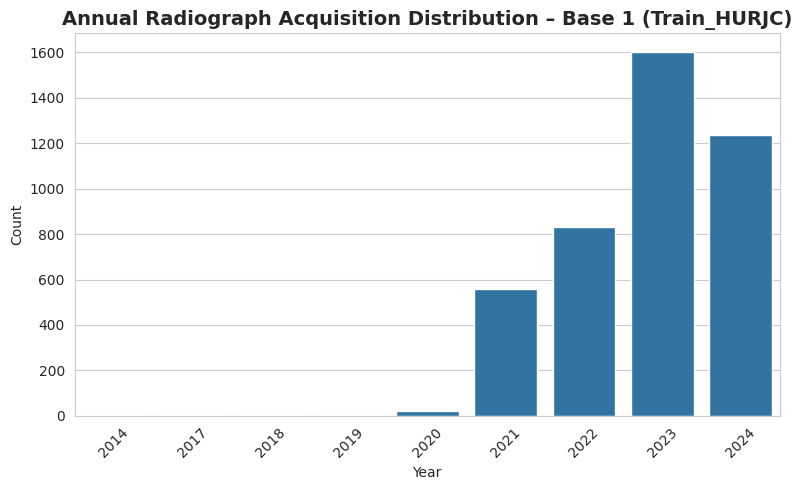


Base 2 (Test_HURJC) – Annual frequency table
--------------------------------------------------


col_0,Count,Percentage (%)
2021,2,0.42
2022,2,0.42
2023,9,1.88
2024,77,16.04
2025,390,81.25
TOTAL,480,100.00


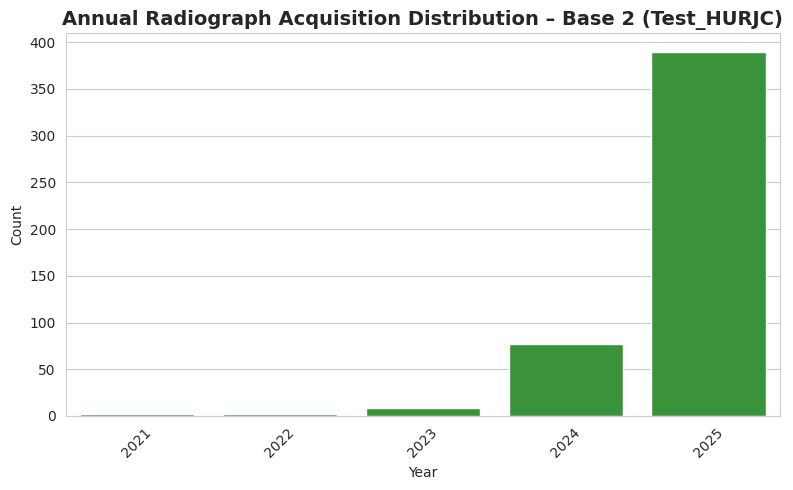


Base 3 (Test_HGV) – Annual frequency table
--------------------------------------------------


col_0,Count,Percentage (%)
2019,3,0.97
2020,4,1.30
2021,3,0.97
2022,7,2.27
2023,55,17.86
2024,150,48.70
2025,86,27.92
TOTAL,308,100.00


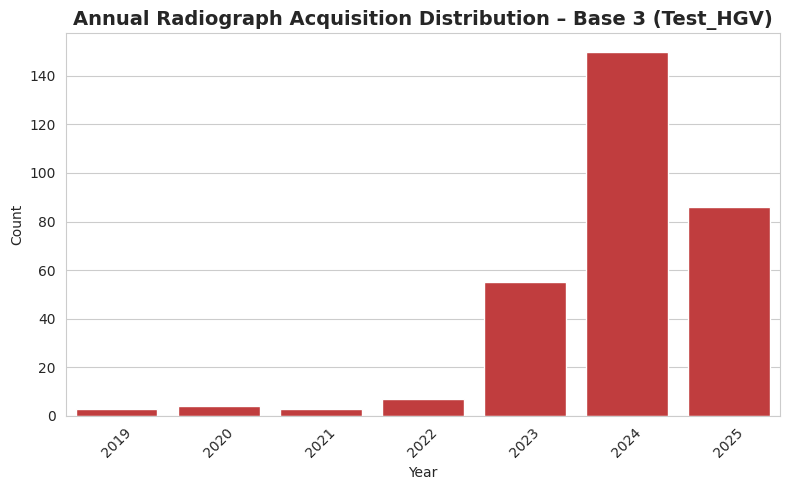

In [27]:
# === Color palettes per dataset (Using the Dark tone for single-color bars) ===
color_b1 = '#1f77b4'  
color_b2 = '#2ca02c' 
color_b3 = '#d62728'  

def analyze_annual_distribution(df, name, color_code):
    # === Setup Output Folder ===
    output_folder = 'Figures/Descriptive_statistics'
    os.makedirs(output_folder, exist_ok=True)

    # Work on a copy to avoid modifying the original DataFrame
    df_tmp = df.copy()

    # Parse dates (standardizing based on your recruitment period 2014-2025)
    df_tmp['date_rx'] = pd.to_datetime(df_tmp['date_rx'], errors='coerce')
    df_tmp = df_tmp.dropna(subset=['date_rx']).copy()

    # Extract year as string for categorical plotting
    df_tmp['date_rx_year'] = df_tmp['date_rx'].dt.year.astype(int).astype(str)

    # === Generate Frequency Table ===
    table = pd.crosstab(index=df_tmp['date_rx_year'], columns='Count')
    table['Percentage (%)'] = (table['Count'] / table['Count'].sum() * 100).round(2)

    # Add TOTAL row for reporting
    total_row = pd.DataFrame(
        data=[[table['Count'].sum(), 100.00]],
        columns=table.columns,
        index=['TOTAL']
    )
    table_final = pd.concat([table, total_row])

    # Show and Save Table
    print(f"\n{name} – Annual frequency table")
    print("-" * 50)
    display(table_final)
    
    table_final.to_csv(f"{output_folder}/{name.replace(' ', '_')}_annual_frequency.csv", index=True)

    # === Annual Distribution Plot ===
    sns.set_style('whitegrid')
    
    # Ensure chronological order
    year_order = sorted(df_tmp['date_rx_year'].unique(), key=lambda x: int(x))

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(
        data=df_tmp,
        x='date_rx_year',
        order=year_order,
        color=color_code,
        ax=ax
    )

    ax.set_title(f'Annual Radiograph Acquisition Distribution – {name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig(f"{output_folder}/annual_distribution_{name.replace(' ', '_')}.png", dpi=300)
    plt.show()

# === Individual Calls for the three cohorts ===

# Base 1 (Train_HURJC) - Blue
analyze_annual_distribution(df_train, "Base 1 (Train_HURJC)", color_b1)

# Base 2 (Test_HURJC) - Green
analyze_annual_distribution(df_internal, "Base 2 (Test_HURJC)", color_b2)

# Base 3 (Test_HGV) - Red
analyze_annual_distribution(df_external, "Base 3 (Test_HGV)", color_b3)

### **8. Summary and Conclusions**

This notebook provides a descriptive overview of the anonymised clinical and imaging dataset used in the experiment. Across all databases, the population spans a wide adult age range with comparable central tendencies, and a balanced representation of sexes and radiographic laterality. The EI and acquisition-related variables show that images were acquired under reasonably consistent technical conditions, although some differences between acquisition systems are evident.

When stratifying by calcific tendinopathy status, patients with and without tendon calcifications showed broadly similar age distributions, and no extreme deviations were observed in EI or basic acquisition parameters between groups. The distributions of projection type, manufacturer and station name reflect the clinical workflows and equipment installed in each centre rather than systematic differences between calcified and non-calcified cases. Importantly, all descriptive summaries were computed on fully anonymised data, without exposing direct identifiers or potentially re-identifying combinations.

The temporal analysis of radiograph counts by year highlights how case accrual varies across the dataset and time, which is relevant for understanding potential temporal shifts in clinical practice or acquisition protocols. Together, these descriptive findings provide essential context for the experiment: they clarify the demographic and technical landscape in which the models were trained and evaluated, help to interpret performance differences between internal and external tests, and support a cautious assessment of how far the learned models can be expected to generalise beyond the specific populations and acquisition conditions represented here.